Columns: Index(['badge_number', 'name', 'age', 'city_department_id'], dtype='str')
   badge_number            name  age  city_department_id
0           100      John Reese   42              101010
1           101    Harold Finch   60              202020
2           102  Jocelyn Carter   38              303030
3           103    Lionel Fusco   44              404040
4           104     Sameen Shaw   25              505050

🌳 Decision Tree
Accuracy: 1.0
              precision    recall  f1-score   support

      101010       1.00      1.00      1.00         1
      202020       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


🌲 Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

      101010       1.00      1.00      1.00         1
      202020       1.00      1.00      1.00         1

    accuracy          

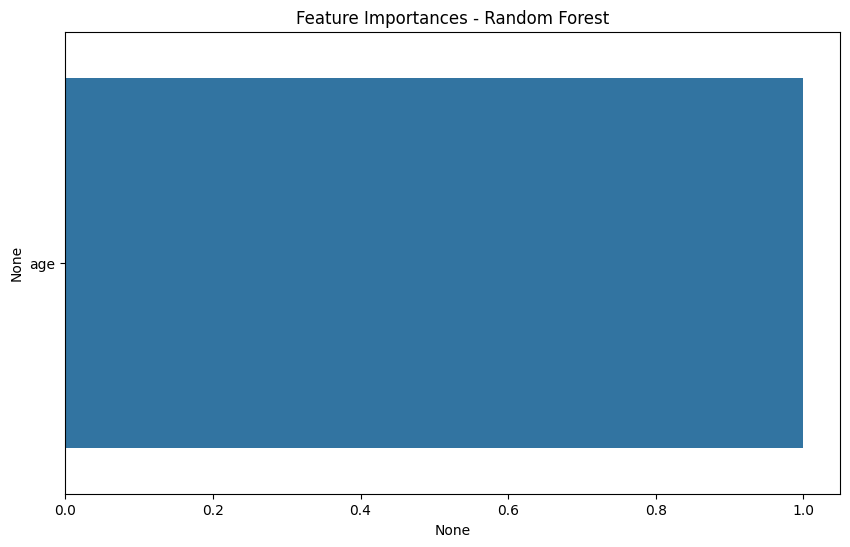

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv('officers_data.csv')

# Clean column names
data.columns = data.columns.str.strip()

print("Columns:", data.columns)
print(data.head())

# -----------------------------
# TARGET COLUMN (FIXED)
# -----------------------------
target_column = 'city_department_id'

# Features & target
X = data.drop(columns=[target_column])
y = data[target_column]

# Drop useless identifier columns (VERY IMPORTANT)
X = X.drop(columns=['badge_number', 'name'], errors='ignore')

# Encode categorical features
label_encoders = {}

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Encode target if needed
if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y.astype(str))
    label_encoders['target'] = le_target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Decision Tree
# -----------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n🌳 Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# -----------------------------
# Random Forest
# -----------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n🌲 Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# -----------------------------
# Feature importance
# -----------------------------
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importances - Random Forest")
plt.show()